In [ ]:
from google.colab import files
uploaded = files.upload()

Saving LA_Data.csv to LA_Data (1).csv
Saving weather_CA_2019.csv to weather_CA_2019 (1).csv


In [ ]:
pollution_df = pd.read_csv("LA_Data.csv")
print(pollution_df.columns.tolist())

['Date', 'Source', 'POC', 'Daily Max 8-hour CO Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Pollutant', 'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']


/tmp/ipython-input-2697884113.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_df["Date"] = pd.to_datetime(weather_df["Date"], errors="coerce")


Correlation with air_temp in Los Angeles (2019):
Carbon monoxide    0.199995
NO2                0.214617
Ozone              0.643628
PM2.5              0.540055
Name: air_temp, dtype: float64


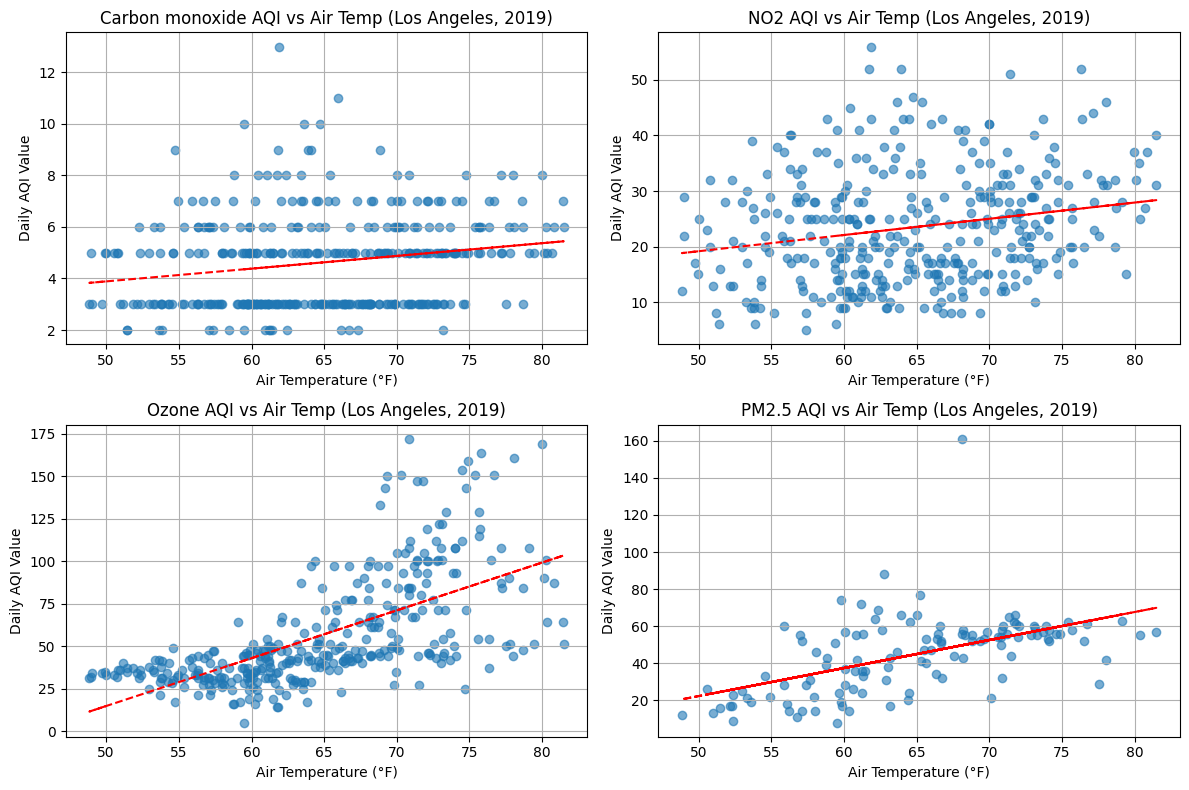

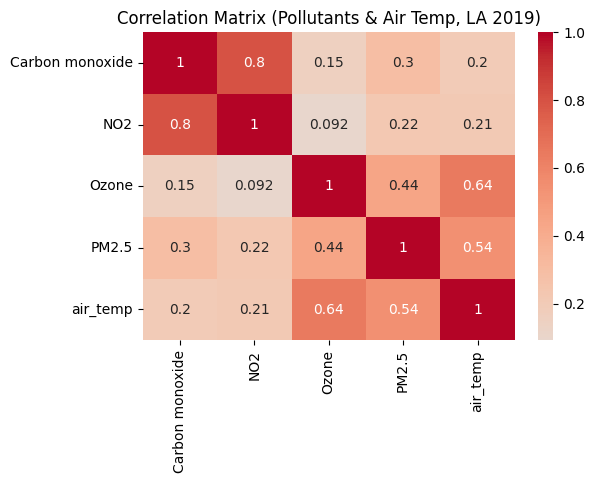

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

aqi_df = pd.read_csv("LA_Data.csv")
weather_df = pd.read_csv("weather_CA_2019.csv")

aqi_df['Date'] = pd.to_datetime(aqi_df['Date'], errors='coerce')

weather_df = weather_df.rename(
    columns={
        "Unnamed: 0": "Date",
        "Unnamed: 1": "Time",
        "Unnamed: 2": "date_time",
        "Statute miles": "visibility",
        "Millibars": "sea_level_pressure",
        "%": "relative_humidity",
        "Miles/hour": "wind_speed",
        "Millibars.1": "sea_level_pressure_2",
        "Fahrenheit": "air_temp",
        "Degrees": "wind_direction",
    }
)

weather_df["Date"] = pd.to_datetime(weather_df["Date"], errors="coerce")
weather_df["air_temp"] = pd.to_numeric(weather_df["air_temp"], errors="coerce")

weather_daily = weather_df.groupby("Date", as_index=False)["air_temp"].mean()

aqi_2019 = aqi_df[aqi_df["Date"].dt.year == 2019]
pollutants = ["Carbon monoxide", "NO2", "Ozone", "PM2.5"]
aqi_2019 = aqi_2019[aqi_2019["Pollutant"].isin(pollutants)]

aqi_pivot = aqi_2019.pivot_table(
    index="Date",
    columns="Pollutant",
    values="Daily AQI Value"
).reset_index()

merged = pd.merge(aqi_pivot, weather_daily, on="Date", how="inner")

corrs = merged[pollutants + ["air_temp"]].corr()
print("Correlation with air_temp in Los Angeles (2019):")
print(corrs["air_temp"].drop("air_temp"))

plt.figure(figsize=(12, 8))
for i, pollutant in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    plt.scatter(merged["air_temp"], merged[pollutant], alpha=0.6)
    mask = merged[["air_temp", pollutant]].dropna()
    if not mask.empty:
        z = np.polyfit(mask["air_temp"], mask[pollutant], 1)
        p = np.poly1d(z)
        plt.plot(mask["air_temp"], p(mask["air_temp"]), "r--")
    plt.title(f"{pollutant} AQI vs Air Temp (Los Angeles, 2019)")
    plt.xlabel("Air Temperature (°F)")
    plt.ylabel("Daily AQI Value")
    plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(corrs, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Pollutants & Air Temp, LA 2019)")
plt.show()